In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,f1_score,recall_score,confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [3]:
from google.colab import files
uploaded=files.upload()

Saving data.csv to data.csv


In [4]:
df=pd.read_csv("data.csv")

In [5]:
print(df)

           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compa

In [6]:
print(df.shape)

(569, 33)


In [7]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [11]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [27]:
print(df.describe())

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [23]:
df.drop("Unnamed: 32",axis=1,inplace=True)

In [17]:
print("Unnamed :32" in df.columns)

False


In [19]:
#To check the duplicate
df.duplicated().sum()

np.int64(0)

In [21]:
df.drop("id",axis=1,inplace=True)

In [28]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


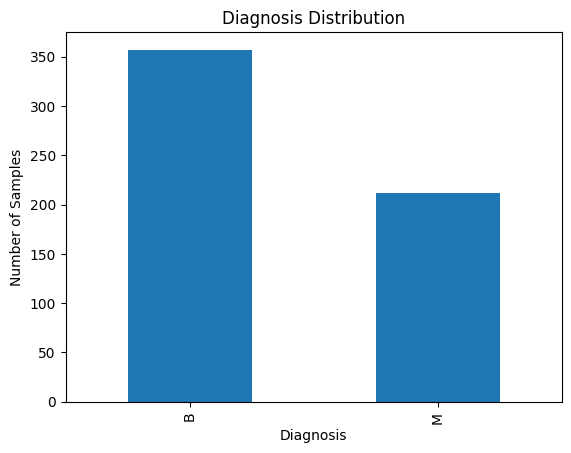

In [29]:
df["diagnosis"].value_counts().plot(kind="bar")

plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

In [35]:
#Now we have cleaned the dataset and Seperate X and y
X=df.drop("diagnosis",axis=1)
y=df["diagnosis"]

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [39]:
print("Shape of training data:",X_train.shape)
print('Shape of testing data:',X_test.shape)
print("Shape of y train:",y_train.shape)
print("Shape of y test:",y_test.shape)

Shape of training data: (455, 30)
Shape of testing data: (114, 30)
Shape of y train: (455,)
Shape of y test: (114,)


In [59]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scacled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [63]:
svm_linear=SVC(kernel="linear",C=1)
svm_linear.fit(X_train_scaled,y_train)

SVC(C=1, kernel='linear')

In [64]:
y_pred=svm_linear.predict(X_test_scaled)

In [65]:
print(y_pred)

['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'M' 'B' 'B' 'M' 'B' 'M' 'B' 'M' 'B' 'B'
 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B'
 'M' 'B' 'M' 'B' 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'M' 'B'
 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M' 'B' 'B' 'B' 'M' 'M' 'B' 'B' 'M' 'M'
 'B' 'M' 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'B' 'M' 'M' 'M' 'M' 'M' 'M' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'M' 'M' 'B' 'B' 'B' 'M'
 'B' 'B' 'M' 'B' 'M' 'M']


In [69]:
results=pd.DataFrame({"Actual":y_test.values,"Predicted":y_pred})
print(results)

    Actual Predicted
0        B         B
1        M         M
2        M         M
3        B         B
4        B         B
..     ...       ...
109      B         B
110      M         M
111      B         B
112      B         M
113      M         M

[114 rows x 2 columns]


In [75]:
#Model Evaluations
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    "Accuracy Percentage:",
    accuracy * 100,
    "%"
)

Accuracy: 0.956140350877193
Accuracy Percentage: 95.6140350877193 %


In [72]:
pre=precision_score(y_test,y_pred, pos_label='M')
print(pre)

0.9318181818181818


In [73]:
conf=confusion_matrix(y_test,y_pred)
print(conf)

[[68  3]
 [ 2 41]]


In [74]:
recall=recall_score(y_test,y_pred,pos_label='M')
print(recall)

0.9534883720930233


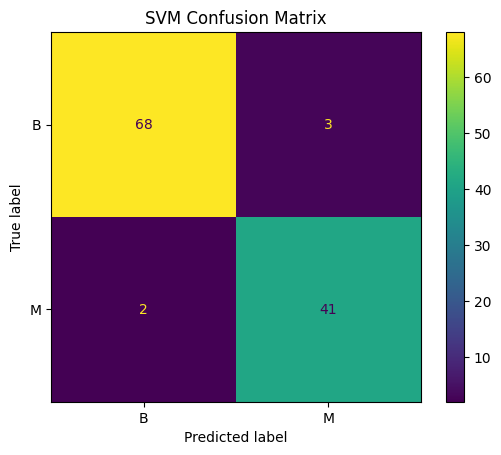

In [80]:
ConfusionMatrixDisplay(
    confusion_matrix=conf,
    display_labels=svm_linear.classes_
).plot()

plt.title("SVM Confusion Matrix")
plt.show()

In [82]:
from sklearn.model_selection import cross_val_score
c_values=[0.01,0.1,1,10,100]
cv_scores=[]
for c in c_values:
  model=SVC(kernel="linear",C=c)
  scores=cross_val_score(model,X_train_scaled,y_train,cv=5,scoring="accuracy")
  cv_scores.append(scores.mean())


In [83]:
for c, score in zip(c_values, cv_scores):
    print(
        f"C = {c}, Mean CV Accuracy = {score:.4f}"
    )

C = 0.01, Mean CV Accuracy = 0.9626
C = 0.1, Mean CV Accuracy = 0.9736
C = 1, Mean CV Accuracy = 0.9692
C = 10, Mean CV Accuracy = 0.9670
C = 100, Mean CV Accuracy = 0.9516
